<a href="https://colab.research.google.com/github/JayAndJef/colabnotebooks/blob/main/FFHQ_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
arnaud58_flickrfaceshq_dataset_ffhq_path = kagglehub.dataset_download('arnaud58/flickrfaceshq-dataset-ffhq')

print('Data source import complete.')


# Variational Autoencoder (VAE) for Face Generation on FFHQ

This notebook implements a Variational Autoencoder (VAE) to learn and reconstruct human faces using the Flickr-Faces-HQ (FFHQ) dataset.

In [ ]:
import kagglehub
arnaud58_flickrfaceshq_dataset_ffhq_path = kagglehub.dataset_download('arnaud58/flickrfaceshq-dataset-ffhq')

print('Data source import complete.')

Data source import complete.


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from PIL import Image
import os
import glob

torch.set_float32_matmul_precision('high')

class FFHQDataset(Dataset):
  def __init__(self, root_dir, transform=None):
    self.root_dir = root_dir
    self.transform = transform
    self.image_paths = []
    # Search for images in the root directory only
    for ext in ('*.png', '*.jpg', '*.jpeg'):
      self.image_paths.extend(glob.glob(os.path.join(root_dir, ext)))

    self.image_paths.sort()
    print(f'Found {len(self.image_paths)} total images in {root_dir}')

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, idx):
    img_path = self.image_paths[idx]
    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image)
    else:
      default_transform = v2.Compose([
        v2.Resize((256, 256)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
      ])
      image = default_transform(image)

    return image

full_dataset = FFHQDataset(root_dir=arnaud58_flickrfaceshq_dataset_ffhq_path, transform=None)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

print(f'Training set size: {len(train_dataset)}')
print(f'Testing set size: {len(test_dataset)}')

if len(train_dataset) > 0:
  images = next(iter(train_loader))
  print(f'Batch shape: {images.shape}')

Found 52001 total images in /kaggle/input/datasets/arnaud58/flickrfaceshq-dataset-ffhq
Training set size: 41600
Testing set size: 10401
Batch shape: torch.Size([64, 3, 256, 256])


In [ ]:
import torch
from torch import nn

class SelfAttention(nn.Module):
  def __init__(self, in_channels, num_heads=4):
    super().__init__()
    self.mha = nn.MultiheadAttention(embed_dim=in_channels, num_heads=num_heads, batch_first=True)
    self.ln = nn.LayerNorm(in_channels)

  def forward(self, x):
    B, C, H, W = x.shape
    residual = x
    # Reshape (B, C, H, W) to (B, H*W, C)
    x_flat = x.permute(0, 2, 3, 1).contiguous().view(B, H * W, C)
    x_normed = self.ln(x_flat)
    attn, _ = self.mha(x_normed, x_normed, x_normed)
    out = attn.view(B, H, W, C).permute(0, 3, 1, 2).contiguous()
    return out + residual

class Encoder(nn.Module):
  def __init__(self, latent_channels=4, in_channels=3):
    super().__init__()
    self.conv = nn.Sequential(
      nn.Conv2d(in_channels, 64, 4, stride=2, padding=1), # 3x256x256 -> 64x128x128
      nn.ReLU(inplace=True),
      nn.Conv2d(64, 128, 4, stride=2, padding=1), # 64x128x128 -> 128x64x64
      nn.ReLU(inplace=True),
      nn.Conv2d(128, 256, 4, stride=2, padding=1), # 128x64x64 -> 256x32x32
      nn.ReLU(inplace=True),
    )
    # Self attention just before the latent bottleneck
    self.attn = SelfAttention(in_channels=256, num_heads=4)

    self.conv_mu = nn.Conv2d(256, latent_channels, 1)
    self.conv_logvar = nn.Conv2d(256, latent_channels, 1)

  def forward(self, x):
    conv_output = self.conv(x)
    attn_output = self.attn(conv_output)
    mu = self.conv_mu(attn_output)
    logvar = self.conv_logvar(attn_output)
    return mu, logvar

class Decoder(nn.Module):
  def __init__(self, latent_channels=4, out_channels=3):
    super().__init__()
    self.initial_conv = nn.Sequential(
      nn.Conv2d(latent_channels, 256, 3, padding=1),
      nn.ReLU(inplace=True)
    )
    self.attn = SelfAttention(in_channels=256, num_heads=4)

    self.deconv = nn.Sequential(
      # 256x32x32 -> 128x64x64
      nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
      nn.ReLU(inplace=True),

      # 128x64x64 -> 64x128x128
      nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
      nn.ReLU(inplace=True),

      # 64x128x128 -> 3x256x256
      nn.ConvTranspose2d(64, out_channels, 4, stride=2, padding=1),
      nn.Tanh(),
    )

  def forward(self, z):
    x = self.initial_conv(z)
    x = self.attn(x)
    return self.deconv(x)

class VAE(nn.Module):
  def __init__(self, image_channels=3, latent_channels=4):
    super().__init__()
    self.encoder = Encoder(latent_channels, image_channels)
    self.decoder = Decoder(latent_channels, image_channels)

  def reparam(self, mu, logvar):
    """
    reparameterization trick to keep gradients
    """
    std = torch.exp(logvar * 0.5)
    elipson = torch.randn_like(std)
    return mu + elipson * std

  def forward(self, x):
    mu, logvar = self.encoder(x)
    z = self.reparam(mu, logvar)
    return self.decoder(z), mu, logvar


In [ ]:
import torch.nn.functional as F

def vae_loss(x_out, x, mu, logvar, beta=1e-4):
  mse_term = F.mse_loss(x_out, x) * 0.2
  L1_term = F.l1_loss(x_out, x) * 0.8
  kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
  kl_term = kl_loss * beta
  return mse_term + L1_term + kl_term, mse_term, L1_term, kl_term

True


Epoch [1/15]: 100%|██████████| 650/650 [04:55<00:00,  2.20it/s, L1=0.0443, kl=0.00833, logvar_mean=-3.98, loss=0.0541, mse=0.00147, mu_mean=0.0652, mu_std=1.07]  

Checkpoint saved for epoch 1


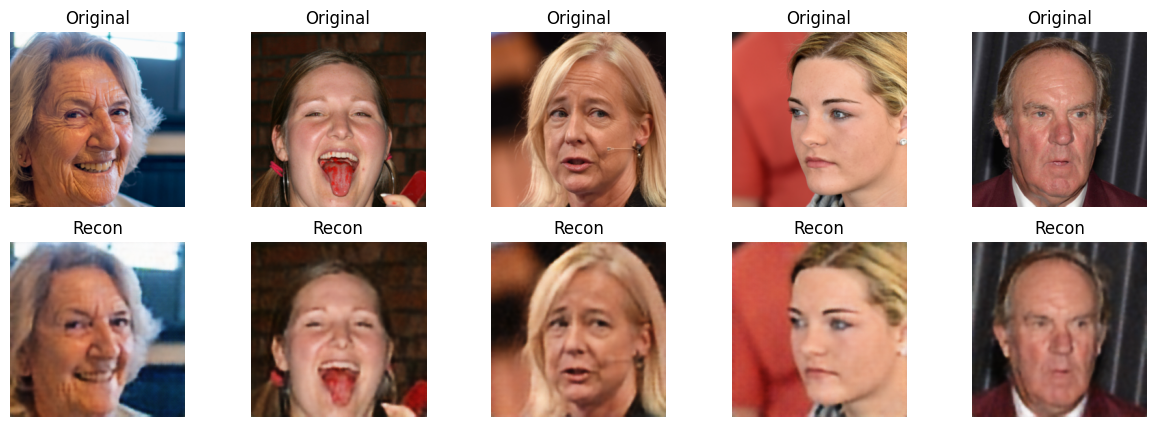

Epoch [2/15]: 100%|██████████| 650/650 [04:51<00:00,  2.23it/s, L1=0.0395, kl=0.0117, logvar_mean=-2.94, loss=0.0523, mse=0.00115, mu_mean=0.0465, mu_std=0.93]    

Checkpoint saved for epoch 2


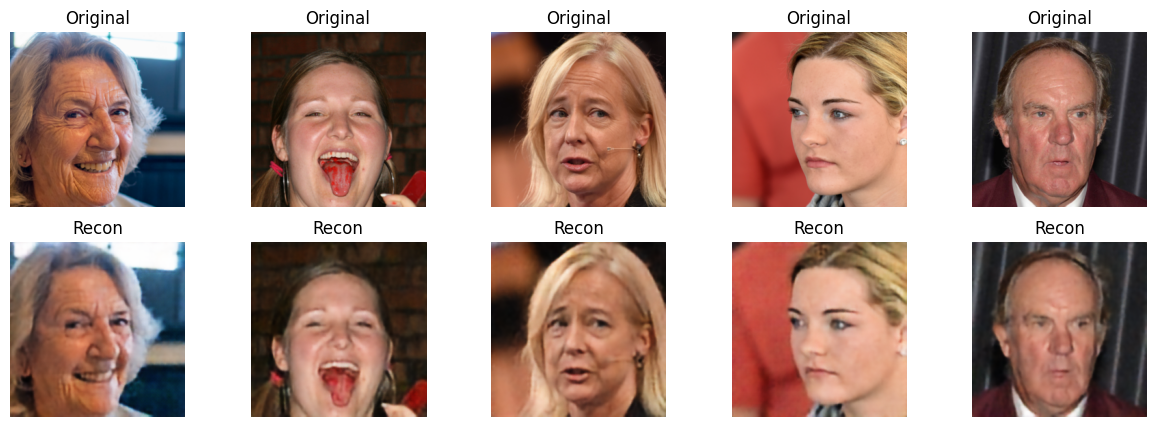

Epoch [3/15]: 100%|██████████| 650/650 [04:46<00:00,  2.27it/s, L1=0.0377, kl=0.0138, logvar_mean=-2.3, loss=0.0526, mse=0.00104, mu_mean=0.0222, mu_std=0.86]     

Checkpoint saved for epoch 3


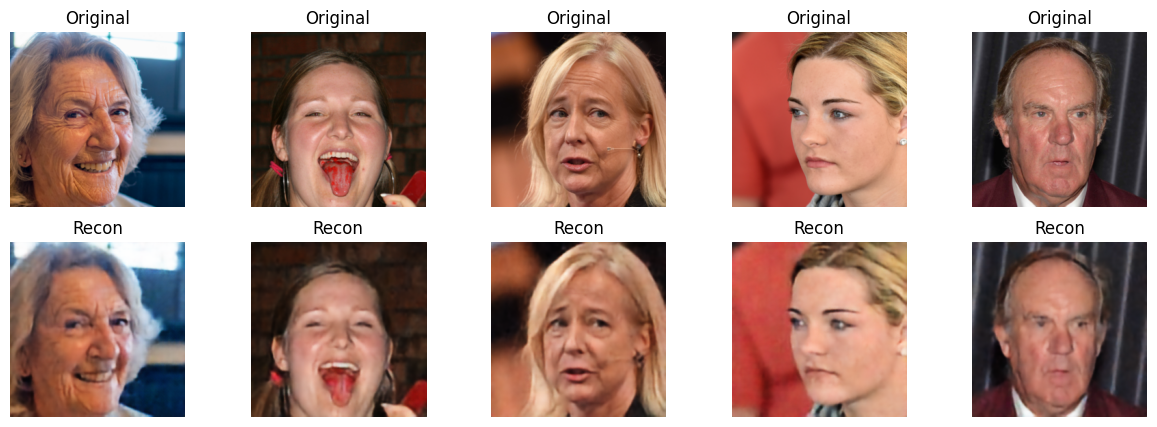

Epoch [4/15]: 100%|██████████| 650/650 [04:45<00:00,  2.28it/s, L1=0.0366, kl=0.0148, logvar_mean=-1.87, loss=0.0524, mse=0.000993, mu_mean=0.0271, mu_std=0.78]   

Checkpoint saved for epoch 4


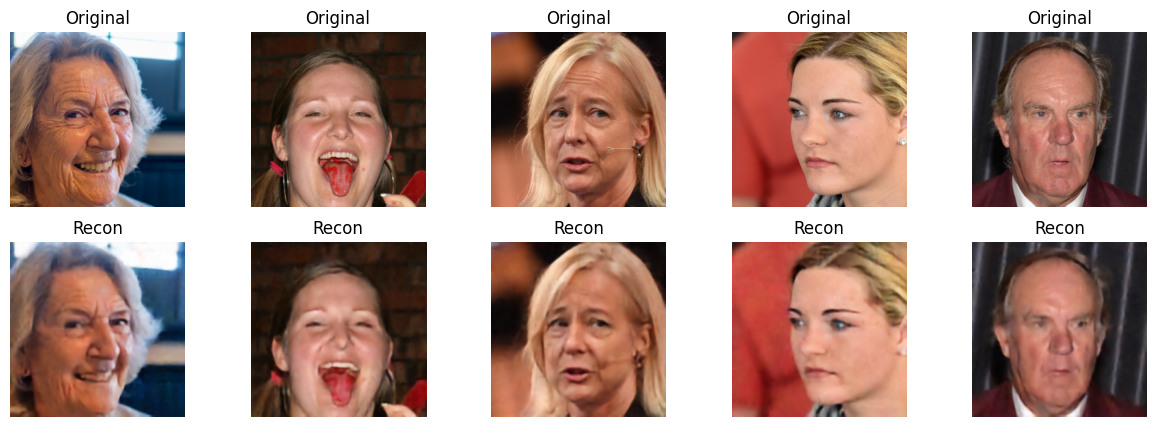

Epoch [5/15]: 100%|██████████| 650/650 [04:45<00:00,  2.27it/s, L1=0.0404, kl=0.0162, logvar_mean=-1.59, loss=0.0577, mse=0.00118, mu_mean=-0.00238, mu_std=0.772] 

Checkpoint saved for epoch 5


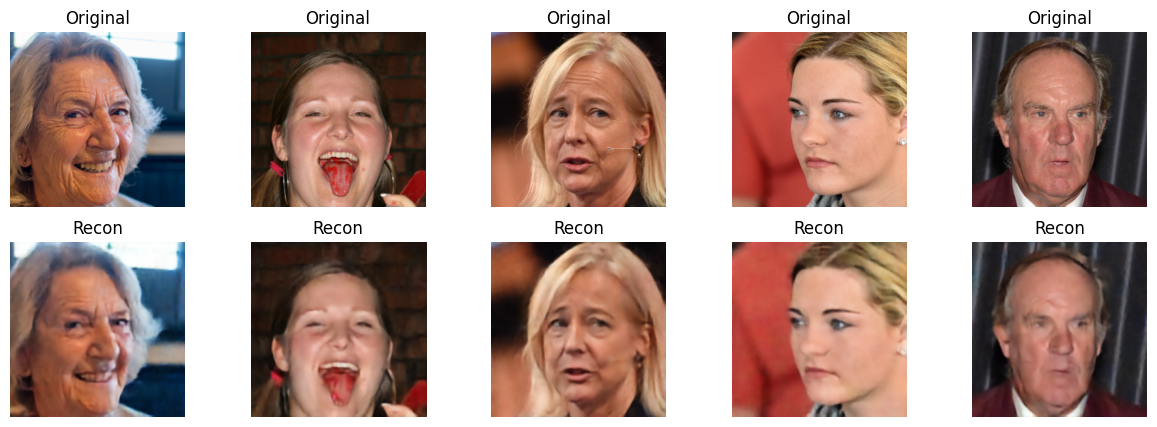

Epoch [6/15]: 100%|██████████| 650/650 [04:46<00:00,  2.27it/s, L1=0.0396, kl=0.0186, logvar_mean=-1.52, loss=0.0594, mse=0.00119, mu_mean=0.00517, mu_std=0.743]  

Checkpoint saved for epoch 6


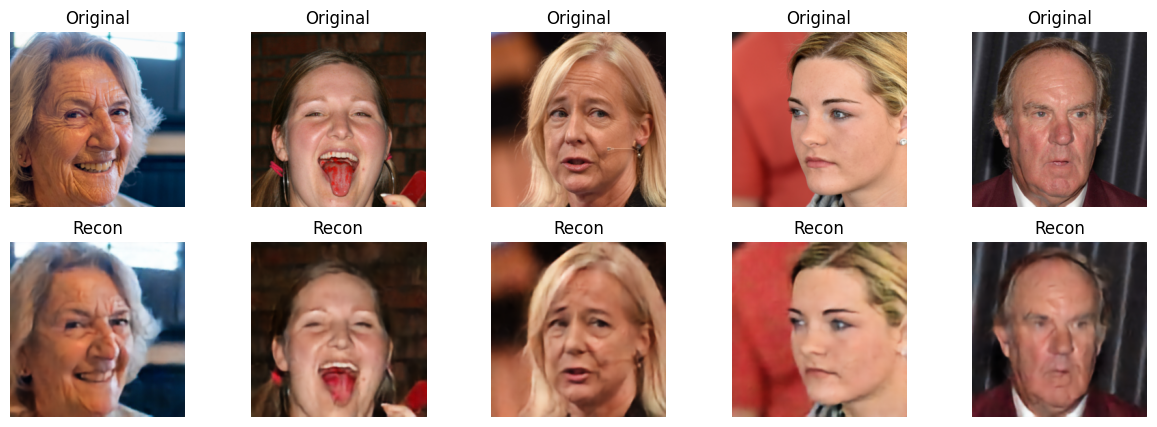

Epoch [7/15]: 100%|██████████| 650/650 [04:45<00:00,  2.27it/s, L1=0.0394, kl=0.0195, logvar_mean=-1.38, loss=0.0601, mse=0.00115, mu_mean=-0.0104, mu_std=0.709]  

Checkpoint saved for epoch 7


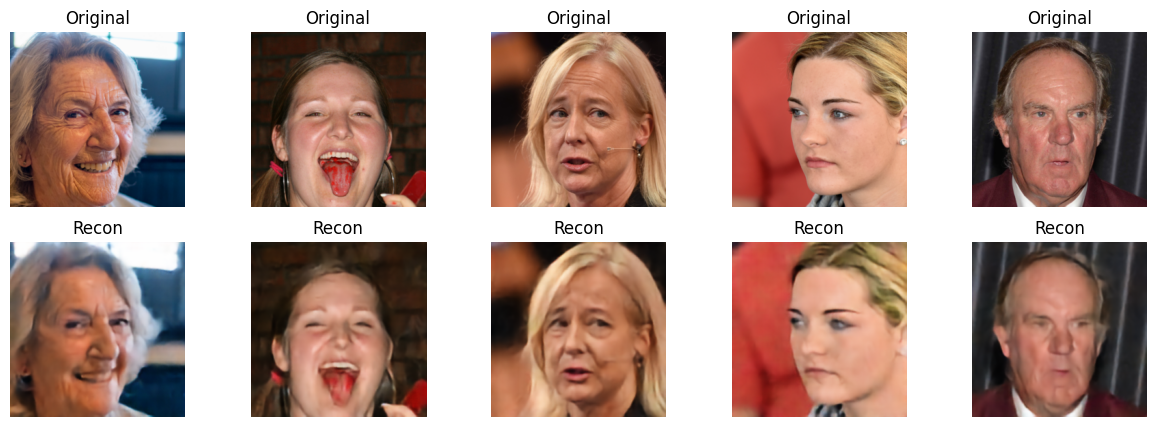

Epoch [8/15]: 100%|██████████| 650/650 [04:46<00:00,  2.27it/s, L1=0.0393, kl=0.0186, logvar_mean=-1.26, loss=0.059, mse=0.00112, mu_mean=-0.00429, mu_std=0.656]  

Checkpoint saved for epoch 8


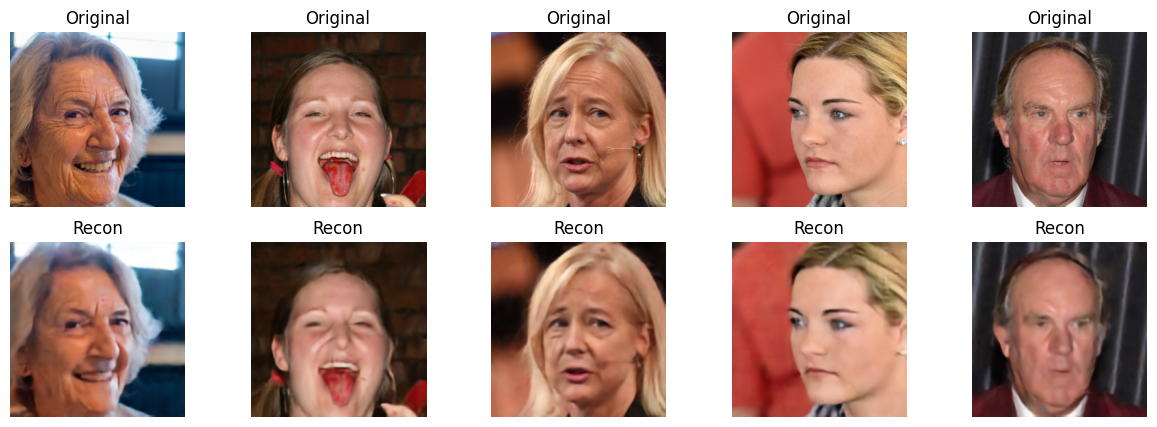

Epoch [9/15]: 100%|██████████| 650/650 [04:46<00:00,  2.27it/s, L1=0.0397, kl=0.0191, logvar_mean=-1.29, loss=0.06, mse=0.0012, mu_mean=0.00902, mu_std=0.667]     

Checkpoint saved for epoch 9


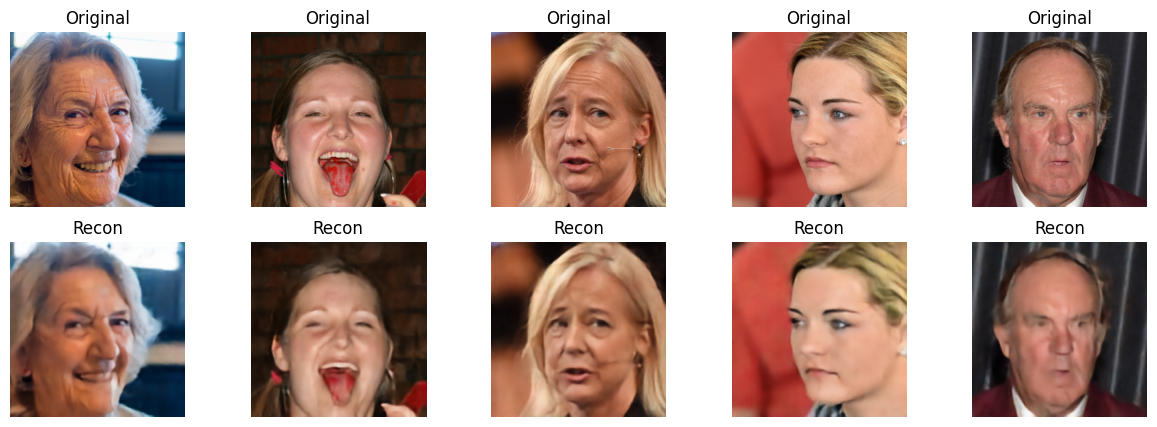

Epoch [10/15]: 100%|██████████| 650/650 [04:47<00:00,  2.26it/s, L1=0.04, kl=0.0194, logvar_mean=-1.28, loss=0.0607, mse=0.00125, mu_mean=0.0136, mu_std=0.678]     

Checkpoint saved for epoch 10


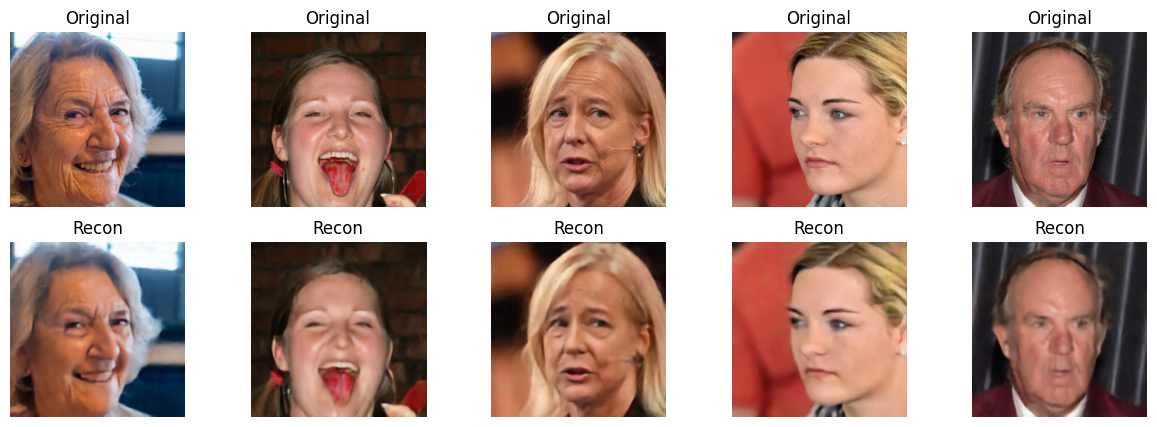

Epoch [11/15]: 100%|██████████| 650/650 [04:44<00:00,  2.28it/s, L1=0.0391, kl=0.0192, logvar_mean=-1.28, loss=0.0594, mse=0.00115, mu_mean=-0.00418, mu_std=0.667] 

Checkpoint saved for epoch 11


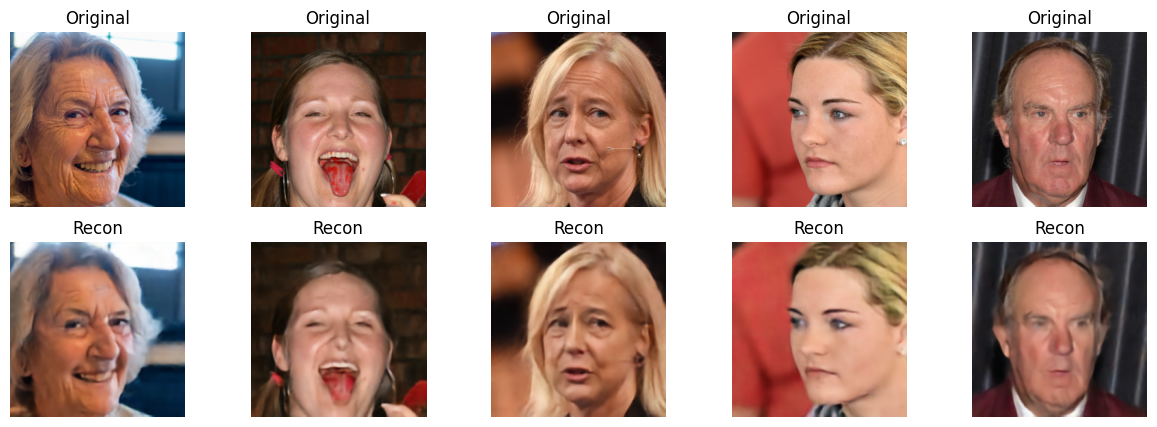

Epoch [12/15]: 100%|██████████| 650/650 [04:45<00:00,  2.27it/s, L1=0.0378, kl=0.0193, logvar_mean=-1.29, loss=0.0581, mse=0.00109, mu_mean=-0.0103, mu_std=0.668]   

Checkpoint saved for epoch 12


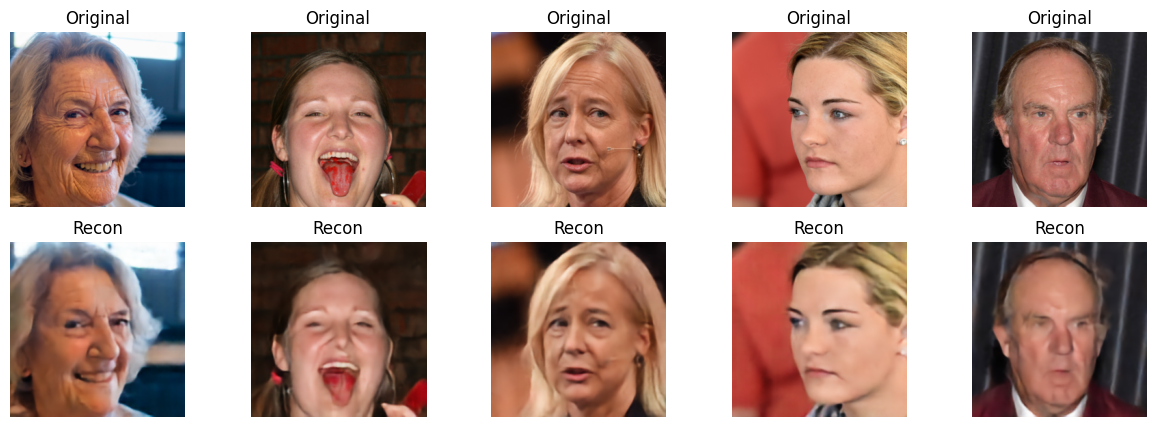

Epoch [13/15]:   0%|          | 0/650 [00:00<?, ?it/s]

In [ ]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch import nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.cuda.is_available())
vae = VAE(latent_channels=8).to(device)
if torch.cuda.device_count() > 1:
    vae = nn.DataParallel(vae)
vae = torch.compile(vae)
optimizer = Adam(vae.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=6)

NUM_EPOCHS = 15

def visualize_reconstruction(model, dataloader, device):
  model.eval()
  with torch.no_grad():
    batch = next(iter(dataloader))
    x = batch.to(device)
    x_out, _, _ = model(x)

    plt.figure(figsize=(15, 5))
    for i in range(5):
      plt.subplot(2, 5, i + 1)
      img_original = ((x[i].cpu().permute(1, 2, 0) * 0.5) + 0.5) * 255
      plt.imshow(img_original.clamp(0, 255).to(torch.uint8).numpy())
      plt.title("Original")
      plt.axis('off')

      plt.subplot(2, 5, i + 6)
      img_recon = ((x_out[i].cpu().permute(1, 2, 0) * 0.5) + 0.5) * 255
      plt.imshow(img_recon.clamp(0, 255).to(torch.uint8).numpy())
      plt.title("Recon")
      plt.axis('off')
    plt.show()
  model.train()

total_steps = NUM_EPOCHS * len(train_loader)
current_step = 0
target_beta = 1e-2 * 3

for epoch in range(NUM_EPOCHS):
  vae.train()
  epoch_loss = 0
  loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
  for batch in loop:
    beta = min(target_beta, target_beta * (current_step / (total_steps * 0.5)))
    current_step += 1
    x = batch.to(device)
    x_out, mu, logvar = vae(x)
    loss, mse, L1, kl = vae_loss(x_out, x, mu, logvar, beta=beta)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
    optimizer.step()

    epoch_loss += loss.item()
    loop.set_postfix(loss=loss.item(), mse=mse.item(), L1=L1.item(), kl=kl.item(), mu_mean=mu.mean().item(), mu_std=mu.std().item(), logvar_mean=logvar.mean().item())

  avg_loss = epoch_loss / len(train_loader)
  scheduler.step(avg_loss)

  torch.save(vae.state_dict(), f'/kaggle/working/vae_checkpoint.pth')
  print(f"Checkpoint saved for epoch {epoch+1}")
  visualize_reconstruction(vae, test_loader, device)


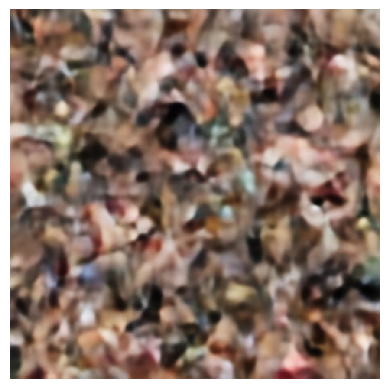

In [ ]:
vae.eval()
z = torch.randn(1, 8, 32, 32).to(device)

unwrapped_model = vae
if hasattr(unwrapped_model, "module"):
    unwrapped_model = unwrapped_model.module
if hasattr(unwrapped_model, "_orig_mod"):
    unwrapped_model = unwrapped_model._orig_mod

with torch.no_grad():
    sample = unwrapped_model.decoder(z)
    sample = ((sample[0].cpu().permute(1, 2, 0) * 0.5) + 0.5).clamp(0, 1)

plt.imshow(sample.numpy())
plt.axis('off')
plt.show()